# Phân tích Cân bằng Công việc - Cuộc sống (Work-Life Balance EDA)

**Mục tiêu của Notebook này:**
1. Đánh giá Điểm Cân bằng công việc - cuộc sống (WLB Score) giữa các nhóm Remote, Hybrid và Onsite.
2. Phân tích sự chênh lệch về số giờ làm việc thực tế (Hours_Per_Week) giữa các hình thức làm việc.
3. Tìm ra "điểm bùng phát" (tipping point) nơi số giờ làm việc bắt đầu tỷ lệ thuận với mức độ kiệt sức (Burnout Level).

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from src.data.load_data import load_raw_data
from src.features.build_features import get_da_data,get_ds_data

In [3]:
sns.set_theme(style='whitegrid')
df = load_raw_data()
df_clean = get_da_data(df)

### 1. Hình thức làm việc nào mang lại điểm Work-Life Balance cao nhất?
Giả thuyết đặt ra là nhóm Hybrid sẽ có điểm WLB cao nhất vì họ kết hợp được ưu điểm của cả hai hình thức. Chúng ta sẽ dùng biểu đồ KDE để kiểm chứng điều này.

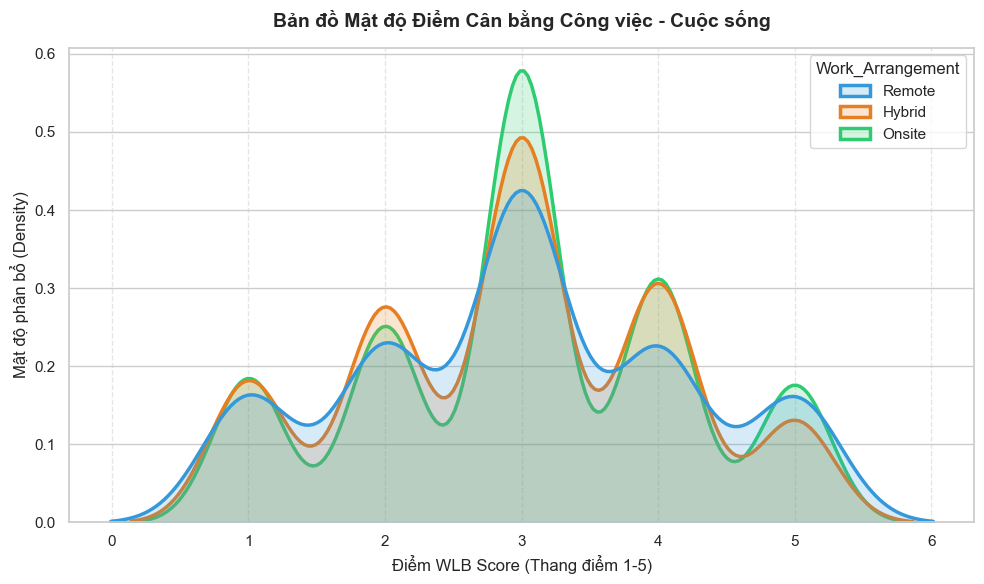

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Cấu hình màu sắc đồng nhất
colors_work = {'Remote': '#3498db', 'Hybrid': '#e67e22', 'Onsite': '#2ecc71'}

# Vẽ biểu đồ mật độ phân phối xếp chồng
sns.kdeplot(
    data=df_clean, 
    x='Work_Life_Balance_Score', 
    hue='Work_Arrangement', 
    hue_order=['Remote', 'Hybrid', 'Onsite'],
    palette=colors_work,
    fill=True,          # Đổ bóng vùng dưới đường cong
    alpha=0.2,          # Độ trong suốt để không bị che nhau
    linewidth=2.5,
    common_norm=False   # Chuẩn hóa độc lập cho từng nhóm để so sánh công bằng
)

plt.title('Bản đồ Mật độ Điểm Cân bằng Công việc - Cuộc sống', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Điểm WLB Score (Thang điểm 1-5)', fontsize=12)
plt.ylabel('Mật độ phân bổ (Density)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [5]:
import scipy.stats as stats

# Tách dữ liệu thành 3 nhóm độc lập
remote_wlb = df_clean[df_clean['Work_Arrangement'] == 'Remote']['Work_Life_Balance_Score']
hybrid_wlb = df_clean[df_clean['Work_Arrangement'] == 'Hybrid']['Work_Life_Balance_Score']
onsite_wlb = df_clean[df_clean['Work_Arrangement'] == 'Onsite']['Work_Life_Balance_Score']

# Thực hiện kiểm định ANOVA một yếu tố (One-way ANOVA)
f_stat, p_val = stats.f_oneway(remote_wlb, hybrid_wlb, onsite_wlb)

print("--- KẾT QUẢ KIỂM ĐỊNH MÔ HÌNH THỐNG KÊ ---")
print(f"Giá trị F-statistic: {f_stat:.4f}")
print(f"Giá trị P-value: {p_val:.4e}")

--- KẾT QUẢ KIỂM ĐỊNH MÔ HÌNH THỐNG KÊ ---
Giá trị F-statistic: 1.4674
Giá trị P-value: 2.3068e-01


**Nhận Xét: Kiểm định Thống kê: WLB Score theo Hình thức Làm việc**
* Biểu đồ mật độ cho thấy phân phối WLB Score của 3 hình thức làm việc có hình dạng gần như trùng khít nhau, đều tập trung đỉnh cao nhất tại điểm 3/5 — trong đó Onsite có đỉnh nhọn hơn (density ~0.58), Remote phân tán đều hơn.
* Kết quả kiểm định One-Way ANOVA ghi nhận F-statistic = 1.4674 và p-value = 0.2307 (>> 0.05), cho thấy biến thiên giữa các nhóm không đáng kể và không có ý nghĩa thống kê.

Không đủ cơ sở bác bỏ H₀ — Hình thức làm việc (Remote / Hybrid / Onsite) không tạo ra sự khác biệt có ý nghĩa về điểm Cân bằng Công việc - Cuộc sống. Cảm quan quan sát từ biểu đồ mật độ được kiểm định thống kê xác nhận: WLB Score phân phối tương đồng giữa cả 3 nhóm.

### 2. Số giờ làm việc thực tế có sự chênh lệch ra sao?
Liệu làm việc ở nhà (Remote) có khiến nhân viên phải làm thêm giờ (Overtime) vô hình nhiều hơn so với việc đến văn phòng (Onsite)?

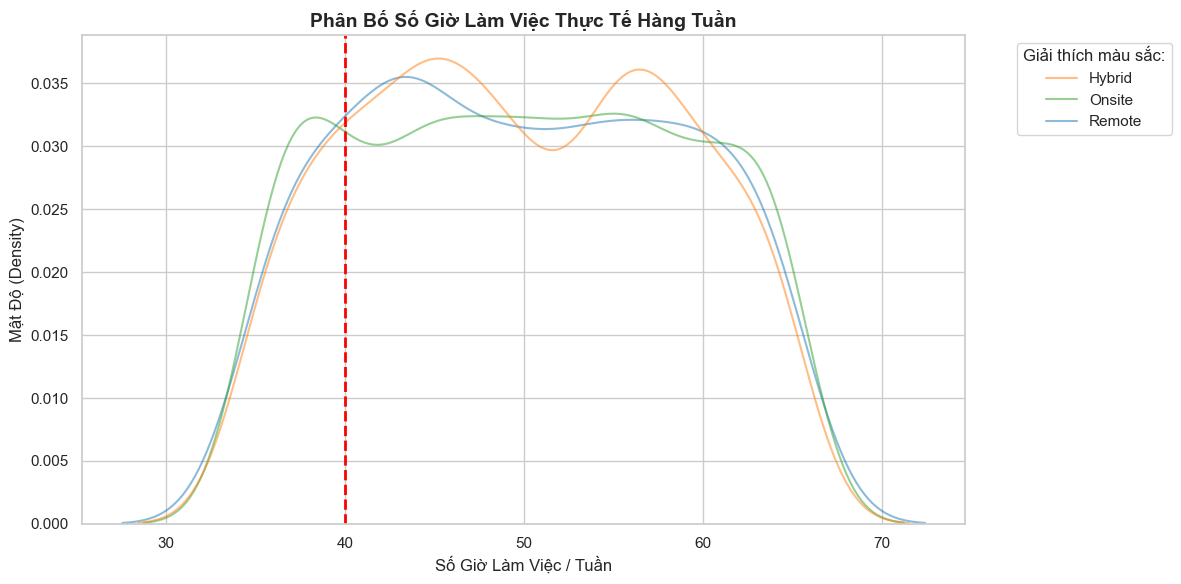

In [6]:
# Cố định màu sắc cho các hình thức làm việc
work_colors = {
    'Remote': '#1f77b4',  # Xanh lam
    'Hybrid': '#ff7f0e',  # Cam
    'Onsite': '#2ca02c'   # Xanh lá
}

plt.figure(figsize=(12, 6))
ax = sns.kdeplot(data=df_clean, x='Hours_Per_Week', hue='Work_Arrangement', 
                 fill=False, common_norm=False, palette=work_colors, alpha=0.5)

plt.title('Phân Bố Số Giờ Làm Việc Thực Tế Hàng Tuần', fontsize=14, fontweight='bold')
plt.xlabel('Số Giờ Làm Việc / Tuần', fontsize=12)
plt.ylabel('Mật Độ (Density)', fontsize=12)
plt.axvline(40, color='red', linestyle='--', linewidth=2, label='Tiêu chuẩn (40h/tuần)')
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1.05, 1), 
                title='Giải thích màu sắc:', frameon=True)
plt.tight_layout() 
plt.show()

**Nhận xét: Phân Bố Số Giờ Làm Việc Thực Tế theo Hình thức Làm việc**
* Biểu đồ mật độ cho thấy cả 3 hình thức làm việc có phân phối gần như tương đồng, trải dài từ ~28 đến ~70 giờ/tuần. Đường kẻ đỏ tại 40 giờ (chuẩn làm việc) chia rõ hai vùng: phần lớn mật độ nằm bên phải — tức đa số nhân viên làm trên 40 giờ/tuần bất kể hình thức nào.
* Điểm khác biệt nhỏ: Hybrid có mật độ cao hơn ở vùng 50–60 giờ (đỉnh thứ hai rõ hơn), gợi ý nhóm này có xu hướng làm thêm giờ nhiều hơn. Onsite tập trung hơn ở vùng 40–45 giờ, trong khi Remote phân tán đều nhất trên toàn dải.

Remote không phải thủ phạm chính của overtime vô hình — cả 3 hình thức đều có xu hướng làm việc vượt 40 giờ/tuần ở mức tương đương. Nghịch lý thay, Hybrid mới là nhóm có dấu hiệu làm thêm giờ rõ nhất, có thể do áp lực "chứng minh năng suất" ở cả hai môi trường.

### 3. Yếu tố nào "chi phối" mạnh nhất đến Điểm Cân Bằng Công Việc - Cuộc Sống?
Thay vì chỉ đoán mò, chúng ta sẽ dùng Hệ số tương quan Pearson để đo lường mức độ tác động của các biến định lượng (Số giờ làm việc, Mức lương, Mức độ cô lập, Số lượng bệnh lý) lên điểm WLB (Work life balance).

C:\Users\HPC\AppData\Local\Temp\ipykernel_2444\3011153488.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=importance_df.head(15), x='Importance_Pct', y='Feature', palette='magma')


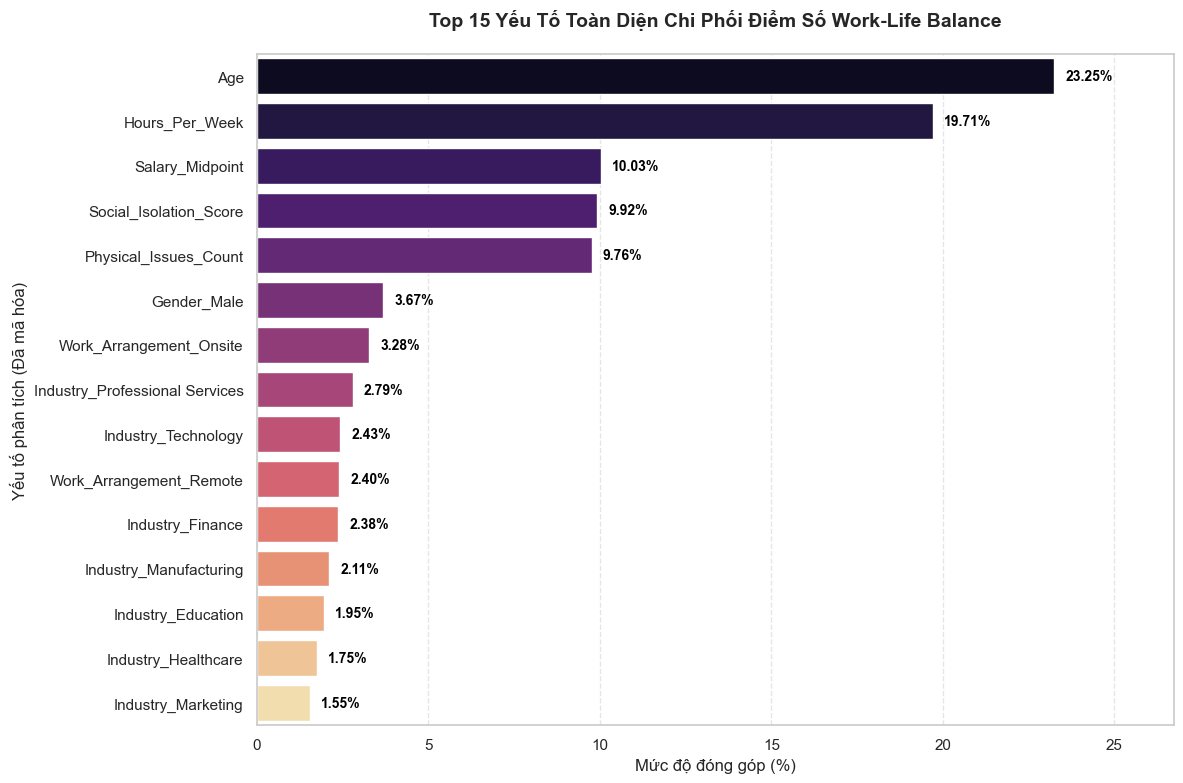

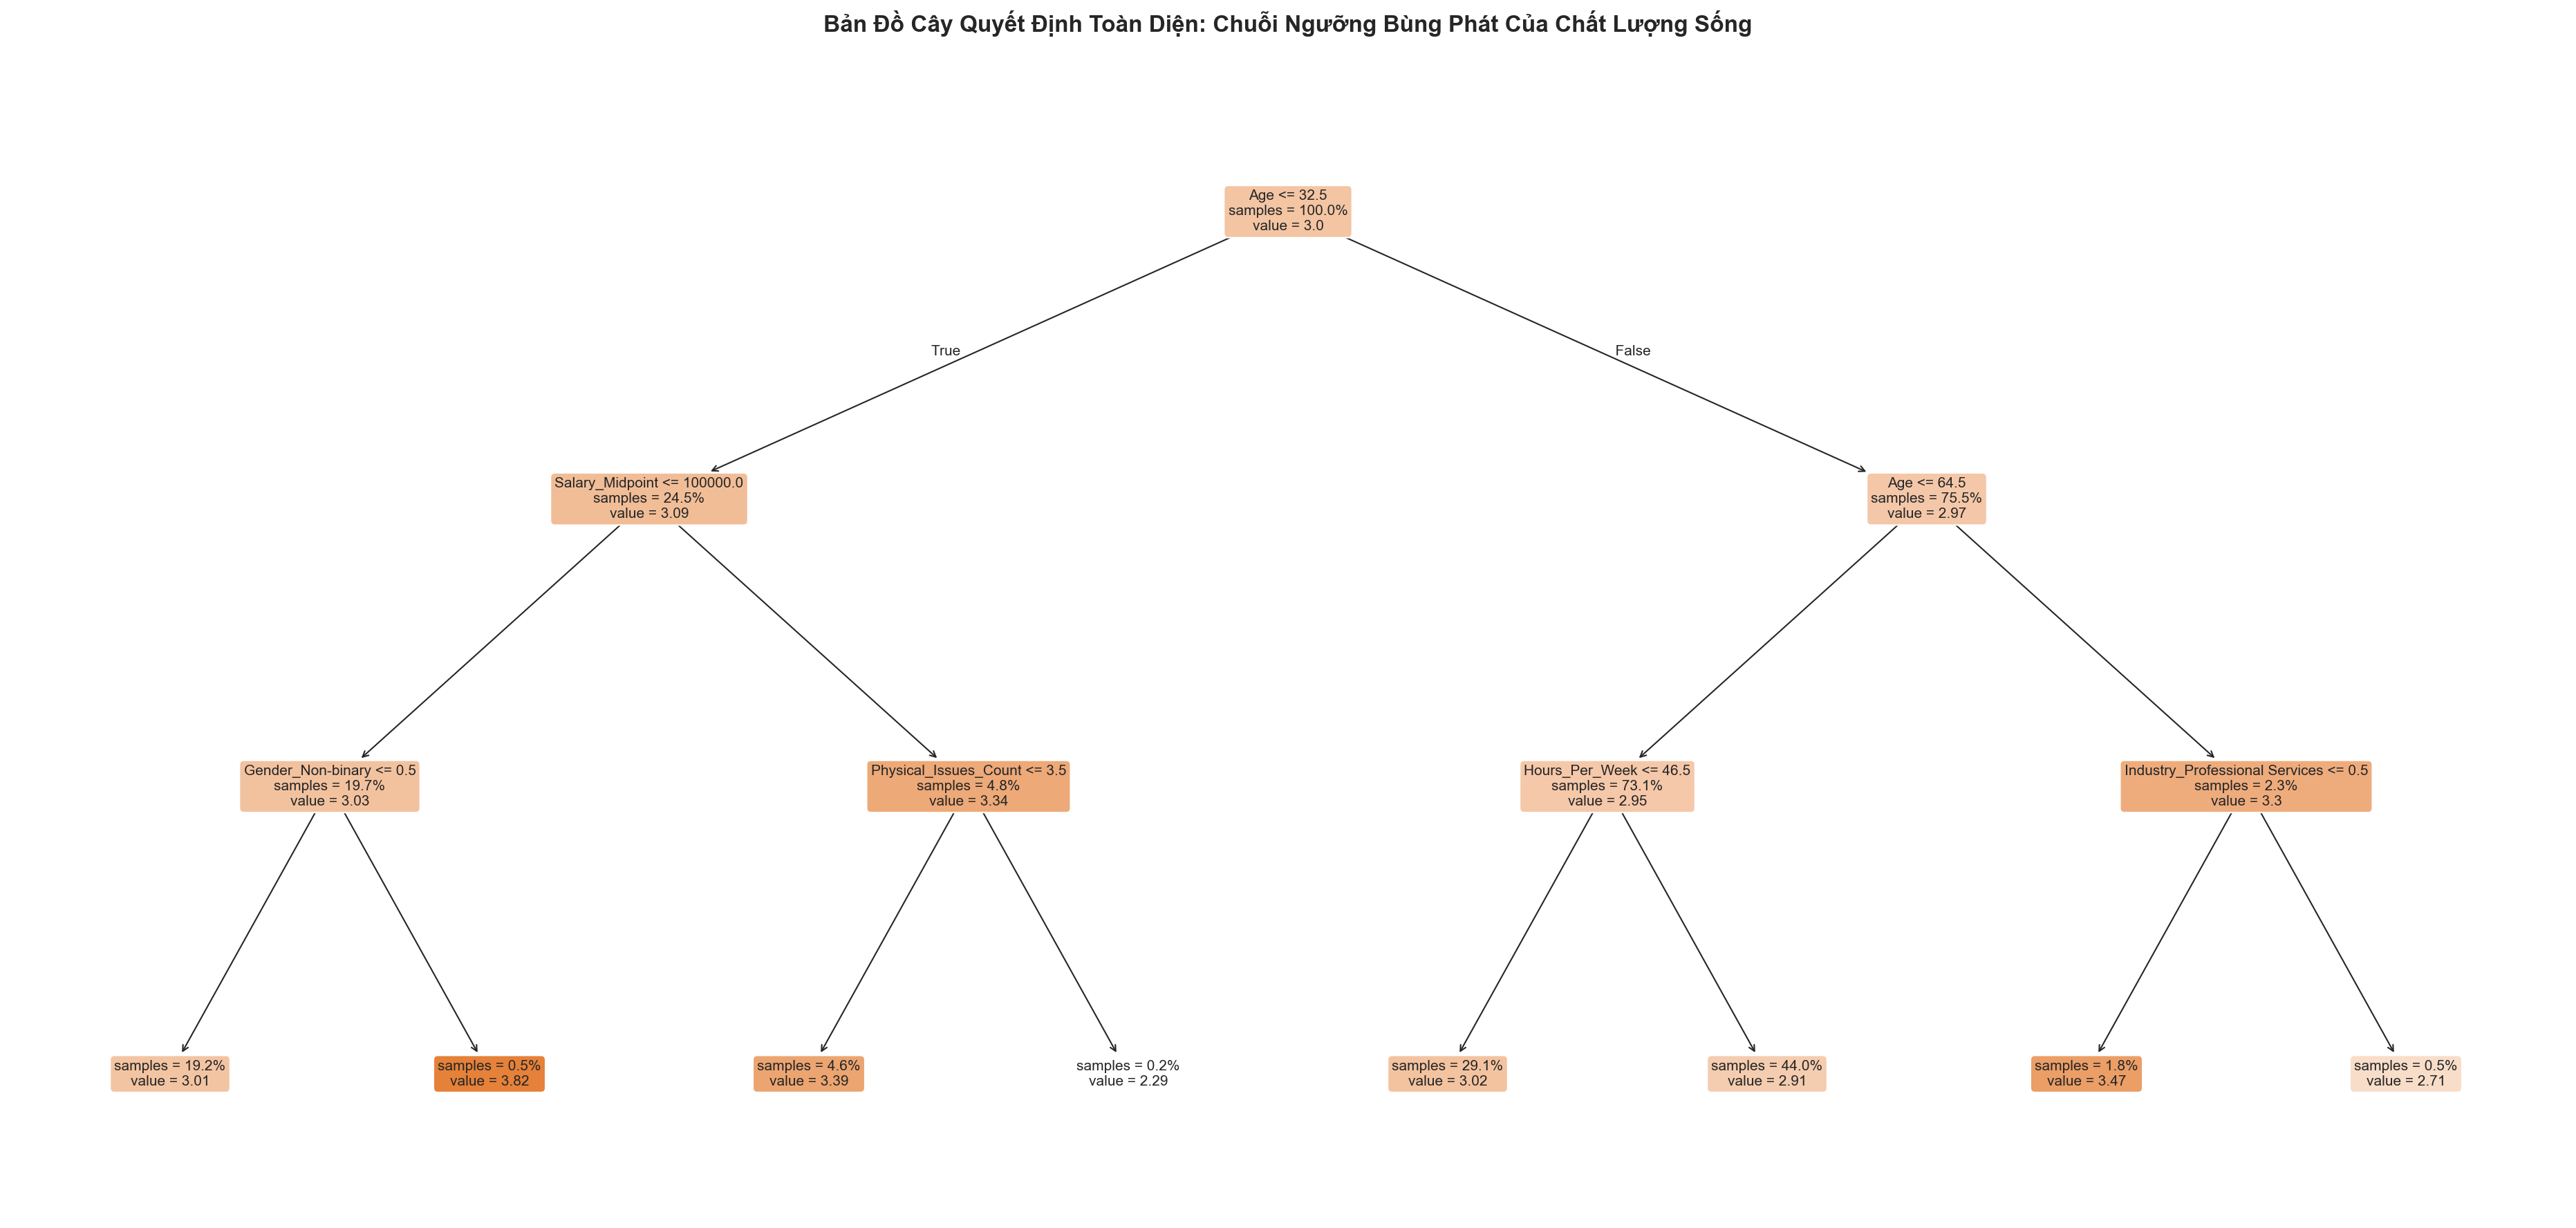

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. Tự động xác định và lọc các biến đầu vào toàn diện (Bao gồm cả Số và Chữ)
target_col = 'Work_Life_Balance_Score'
candidate_features = [
    'Hours_Per_Week', 'Salary_Midpoint', 'Social_Isolation_Score', 'Physical_Issues_Count', 'Age',
    'Work_Arrangement', 'Gender', 'Industry', 'Job_Role'
]

available_features = [col for col in candidate_features if col in df_clean.columns]

X_raw = df_clean[available_features]
y = df_clean[target_col]

# 2. Áp dụng One-Hot Encoding biến các cột chữ thành các biến chỉ báo (0 và 1)
X = pd.get_dummies(X_raw, drop_first=True)

# 3. Huấn luyện Random Forest toàn diện để lấy Feature Importance
rf_all = RandomForestRegressor(n_estimators=100, random_state=42)
rf_all.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Pct': rf_all.feature_importances_ * 100
}).sort_values(by='Importance_Pct', ascending=False)

# --- Biểu đồ 1: Top 15 Yếu tố Chi phối Toàn diện (Đã thêm % trực quan) ---
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=importance_df.head(15), x='Importance_Pct', y='Feature', palette='magma')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=8, fontweight='bold', fontsize=10, color='black')

plt.title('Top 15 Yếu Tố Toàn Diện Chi Phối Điểm Số Work-Life Balance', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mức độ đóng góp (%)', fontsize=12)
plt.ylabel('Yếu tố phân tích (Đã mã hóa)', fontsize=12)

plt.xlim(0, importance_df['Importance_Pct'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Huấn luyện Cây Quyết Định sâu hơn (max_depth=3) để tìm Chuỗi Điểm Gãy Liên Hoàn
tree_all = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_all.fit(X, y)

# --- Biểu đồ 2: Sơ đồ Cây Quyết Định liên hoàn (Tối ưu ô to, thoáng và cực kỳ dễ nhìn) ---
plt.figure(figsize=(25, 12), dpi=150)

plot_tree(
    tree_all, 
    feature_names=list(X.columns), 
    filled=True, 
    rounded=True, 
    fontsize=10,        # TỐI ƯU 3: Tăng font chữ lên kích cỡ 10 giúp hiển thị rõ ràng trên màn hình lớn
    precision=2,
    impurity=False,     # TỐI ƯU 4: Ẩn bớt dòng MSE giúp ô vuông gọn gàng, chữ không bị tràn
    proportion=True     # TỐI ƯU 5: Đổi số lượng dòng tuyệt đối thành % giúp rút ngắn ký tự, ô tự động to ra
)

plt.title('Bản Đồ Cây Quyết Định Toàn Diện: Chuỗi Ngưỡng Bùng Phát Của Chất Lượng Sống', fontsize=16, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()


**Nhận xét: Top 15 Yếu tố & Cây Quyết định Chi phối WLB Score**
* Biểu đồ Feature Importance chỉ ra Age (23.25%) và Hours_Per_Week (19.71%) là hai yếu tố chi phối mạnh nhất — bỏ xa nhóm còn lại. Tiếp theo là Salary_Midpoint (10.03%), Social_Isolation_Score (9.92%) và Physical_Issues_Count (9.76%) tạo thành nhóm tầm trung có ảnh hưởng đáng kể. Các yếu tố như hình thức làm việc, giới tính và ngành nghề chỉ đóng góp dưới 4% — nhất quán với các phân tích trước.

* Cây Quyết định xác nhận logic tương tự: nút gốc phân nhánh đầu tiên tại Age ≤ 32, nhóm trẻ tiếp tục phân tách theo Salary_Midpoint, trong khi nhóm lớn tuổi hơn phân tách theo Hours_Per_Week và Industry.

Tuổi tác và số giờ làm việc mỗi tuần là hai trục quyết định chất lượng Work-Life Balance — không phải nơi làm việc hay ngành nghề. Nhân viên trẻ, thu nhập thấp và làm việc nhiều giờ là nhóm dễ tổn thương nhất cần được ưu tiên hỗ trợ.